In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import BaggingRegressor
from catboost import CatBoostRegressor

from boosted_linear_catboost import get_train_test_data, scoring
from model_selection import compute_n_coords

# Load train, test data

In [3]:
train_x, train_y, test_x, test_y = get_train_test_data()

linear_features = ["salinity"]  # better than when including temperature


2026-04-17 14:43:31.786 | INFO     | model_selection:load_data:184 - Loading data from /Users/luke/Work/OceanCO2/highres_TA/data/training/GLODAPv2023-raw_collocated-YYYY.pq for years 1982-2021
2026-04-17 14:43:32.164 | INFO     | boosted_linear_catboost:get_train_test_data:507 - Training columns: ['salinity', 'temperature', 'bottomdepth', 'ssh_adt', 'chl_globcolour', 'coordsA', 'coordsB', 'coordsC']


# Fit models

In [4]:
import highres_ta.estimators as models

In [103]:
bagged_model = models.BaggingCatBoostResidualRegressor(
    n_estimators=20, 
    polynomial_degree=2,
    max_samples=0.2,
    loss_function="MAE",
    linear_features=linear_features,
    n_jobs=8,
)


In [104]:
bagged_model.fit(train_x, train_y)
train_yhat = bagged_model.predict(train_x)
_ = scoring(train_y, train_yhat)

2026-04-17 15:14:20.058 | INFO     | boosted_linear_catboost:scoring:328 - Scoring: 
|                         |   Scoring Metrics |
|:------------------------|------------------:|
| root_mean_squared_error |           27.6    |
| mean_absolute_error     |           12      |
| huber_loss              |           11.5    |
| median_absolute_error   |            4.95   |
| mean_bias               |           -1.76   |
| median_bias             |           -0.0363 |
| r2_score                |            0.935  |


# Test scores

In [105]:
# the prediction flow:
# 1) get the baseline prediction from the linear model
# 2) get the residual prediction from the bagged booster
# 3) sum them to get the final prediction
test_yhat = bagged_model.predict(test_x)

_ = scoring(test_y, test_yhat)

2026-04-17 15:14:20.183 | INFO     | boosted_linear_catboost:scoring:328 - Scoring: 
|                         |   Scoring Metrics |
|:------------------------|------------------:|
| root_mean_squared_error |          29.7     |
| mean_absolute_error     |          12.2     |
| huber_loss              |          11.7     |
| median_absolute_error   |           5.19    |
| mean_bias               |          -1.45    |
| median_bias             |           0.00672 |
| r2_score                |           0.931   |


# Load inference data (single timestep)

In [106]:
url = "https://data.up.ethz.ch/shared/OceanSODA-ETHZv2/.inference_for_gregor2024/data_8daily_25km_v01.zarr/"
ds = xr.open_zarr(url, consolidated=True, group='2005')

ds["bottomdepth"] = xr.open_dataarray("../data/bathymetry_etopo2022_25km.nc")
rename = dict(
    sss="salinity",
    sst="temperature",
    ssh="ssh_adt",
    ssh_anom="ssh_sla",
    mld="mld_dens_soda",
    chl_filled="chl_globcolour",
    bottomdepth="bottomdepth",
)
ds = ds.rename(rename)[list(rename.values())]
ds = ds.isel(time=33, drop=True)
df = ds.to_dataframe()

coords = df.index.to_frame()
n_coords = compute_n_coords(coords["lat"], coords["lon"])
df = df.join(n_coords)
pred_X = df.dropna()[train_x.columns]

# Create mapped estimates

In [107]:
import numpy as np
full_results = np.vstack((bagged_model.predict(pred_X, return_std=True),
bagged_model.predict_linear(pred_X, return_std=True),
bagged_model.predict_catboost(pred_X, return_std=True),))

In [108]:
pred_y = pd.DataFrame(
    data=full_results.T,
    columns=["mean_prediction", "std_prediction", "mean_linear", "std_linear", "mean_catboost", "std_catboost"],
    index=pred_X.index,
).to_xarray().astype("float32").chunk()
pred_y["std_combined"] = ((pred_y.std_catboost**2 + pred_y.std_linear**2)**0.5).chunk()

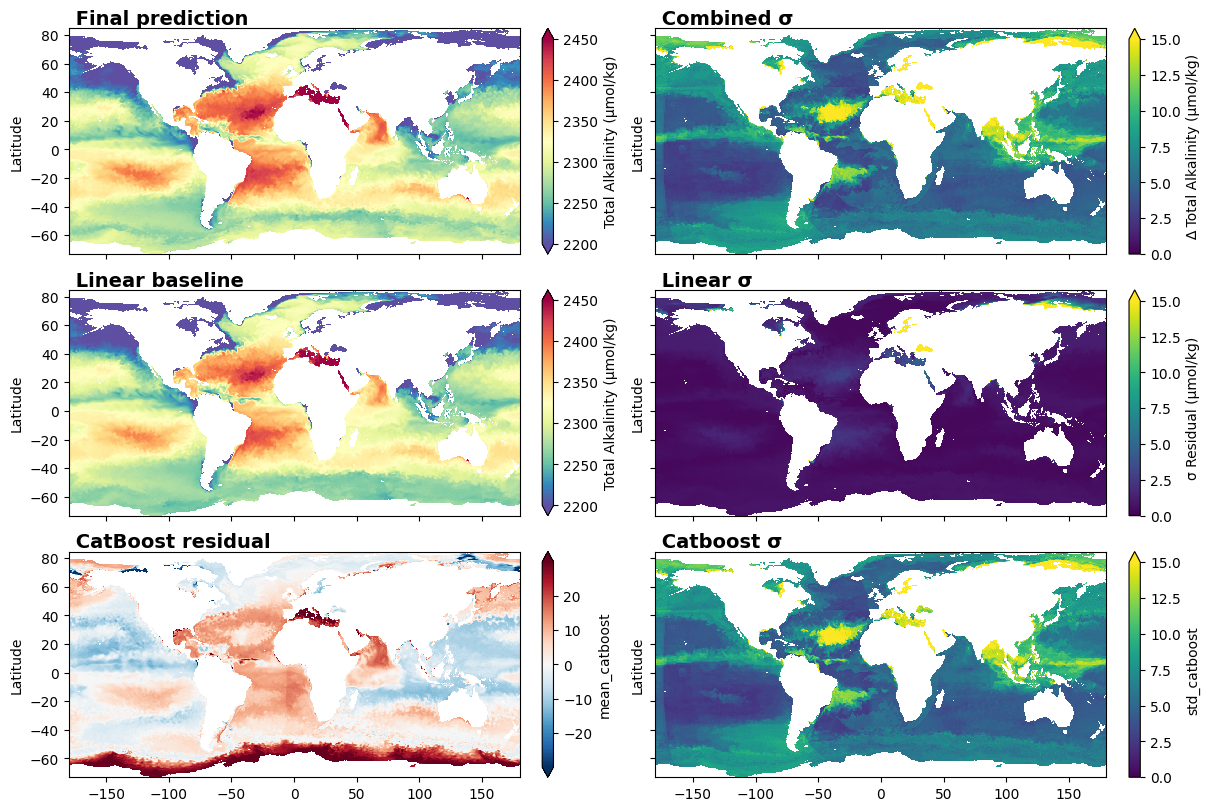

In [109]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 2, figsize=(12, 8), squeeze=False, sharex=True, sharey=True, constrained_layout=True)
img1 = pred_y.mean_prediction.plot.imshow(vmin=2200, vmax=2450, ax=axs[0, 0], cmap="Spectral_r")
img2 = pred_y.std_combined.plot.imshow(vmin=0, vmax=15, ax=axs[0, 1])
img3 = pred_y.mean_linear.plot.imshow(vmin=2200, vmax=2450, ax=axs[1, 0], cmap="Spectral_r")
img4 = pred_y.std_linear.plot.imshow(vmin=0, vmax=15, ax=axs[1, 1])
img5 = pred_y.mean_catboost.plot.imshow(robust=True, ax=axs[2, 0])
img6 = pred_y.std_catboost.plot.imshow(vmin=0, vmax=15, ax=axs[2, 1])

[ax.set_ylabel('') for ax in axs.flat]
[ax.set_xlabel('') for ax in axs.flat]

# img3.get_clim()
# img1.set_clim(img3.get_clim())

img1.colorbar.set_label("Total Alkalinity (µmol/kg)")
img2.colorbar.set_label("∆ Total Alkalinity (µmol/kg)")
img3.colorbar.set_label("Total Alkalinity (µmol/kg)")
img4.colorbar.set_label("σ Residual (µmol/kg)")

text_props = dict(fontsize=14, fontweight='bold', color='black', loc='left', va='top')
axs = axs.flatten()
axs[0].set_title(" Final prediction", **text_props)
axs[1].set_title(" Combined σ", **text_props)
axs[2].set_title(" Linear baseline", **text_props)
axs[3].set_title(" Linear σ", **text_props)
axs[4].set_title(" CatBoost residual", **text_props)
axs[5].set_title(" Catboost σ", **text_props)

for ax in axs.flatten():
    ax.set_xlabel("")
    ax.set_ylabel("Latitude")

<Axes: >

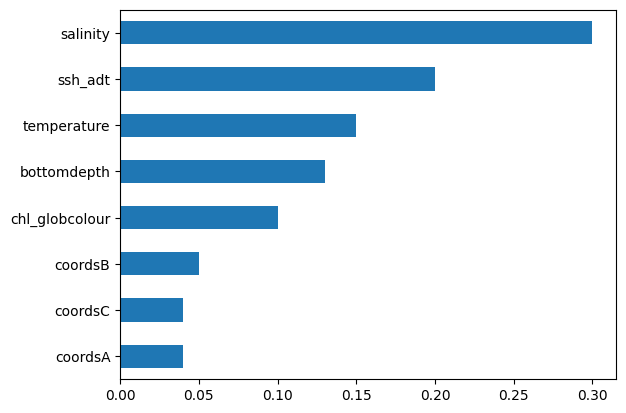

In [117]:
pd.Series(bagged_model.estimators_[0].boosting_model_.get_feature_importance(), index=train_x.columns).pipe(lambda s: s / s.sum()).sort_values(ascending=True).round(2).plot.barh()

Index(['salinity', 'temperature', 'bottomdepth', 'ssh_adt', 'chl_globcolour',
       'coordsA', 'coordsB', 'coordsC'],
      dtype='str')